In [1]:
from mtri_gmsh_helpers import *
import numpy as np
import netCDF4 as nc
import gmsh
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

In [2]:
geometry_filename = "/users/hasanm4/lore.scorec.rpi.edu/wsources/DEGAS2-XGC/simulationRuns/ltx-flighttest/geometry.nc"

ds = nc.Dataset(geometry_filename)

In [3]:
surface_coeffs = ds.variables['surface_coeffs'][:]
cells = ds.variables['cells'][:]
boundaries = ds.variables['boundaries'][:]
surface_points = ds.variables['surface_points'][:]
zone_centers = ds.variables['zone_center'][:]
zone_min = ds.variables['zone_min'][:]
zone_max = ds.variables['zone_max'][:]
surfaces = ds.variables['surfaces'][:]
neighbors = ds.variables['neighbors'][:]

ds.close()

surface_coeffs = np.array(surface_coeffs)
cells = np.array(cells)
boundaries = np.array(boundaries)
surface_points = np.array(surface_points)
zone_centers = np.array(zone_centers)
zone_min = np.array(zone_min)
zone_max = np.array(zone_max)
surfaces = np.array(surfaces)
neighbors = np.array(neighbors)

In [4]:
def read_gmsh_tri_mesh(filename):
    gmsh.initialize()
    gmsh.open(filename)

    # Get node information: node tags and coordinates (x, y, z)
    node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
    
    # Reshape coordinates into a (npoints, 3) array
    # Gmsh returns a flat array of [x1, y1, z1, x2, y2, z2, ...]
    points = node_coords.reshape(-1, 3)
    # sort with node_tags to ensure correct ordering
    sorted_indices = np.argsort(node_tags)
    points = points[sorted_indices]
    

    # get triangle element connectivity
    elm_types, elm_tags, node_tags_per_element = gmsh.model.mesh.getElements(dim=2) # Type 2 is for 3-node triangles
    connectivity = np.array(node_tags_per_element).reshape(-1, 3) -1  # Convert to zero-based indexing
    

    gmsh.finalize()
    
    return mtri.Triangulation(points[:, 0], points[:, 1], triangles=connectivity)


Info    : Reading '/users/hasanm4/lore.scorec.rpi.edu/wsources/DEGAS2-XGC/simulationRuns/ltx-flighttest/withBoundingSq.msh'...
Info    : 2382 nodes
Info    : 5144 elements
Info    : Done reading '/users/hasanm4/lore.scorec.rpi.edu/wsources/DEGAS2-XGC/simulationRuns/ltx-flighttest/withBoundingSq.msh'


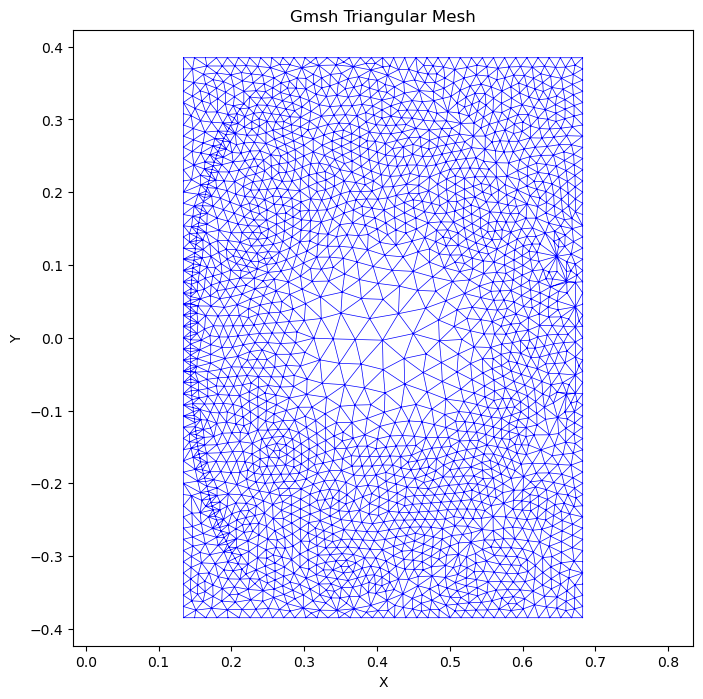

In [5]:
mesh_filename = "/users/hasanm4/lore.scorec.rpi.edu/wsources/DEGAS2-XGC/simulationRuns/ltx-flighttest/withBoundingSq.msh"

mesh = read_gmsh_tri_mesh(mesh_filename)
# plot the mesh
plt.figure(figsize=(8, 8))
plt.triplot(mesh, color='blue', linewidth=0.5)
plt.title('Gmsh Triangular Mesh')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.show()

Cell 3448 boundaries: [5377  311 5374] with signs [-1  1 -1]


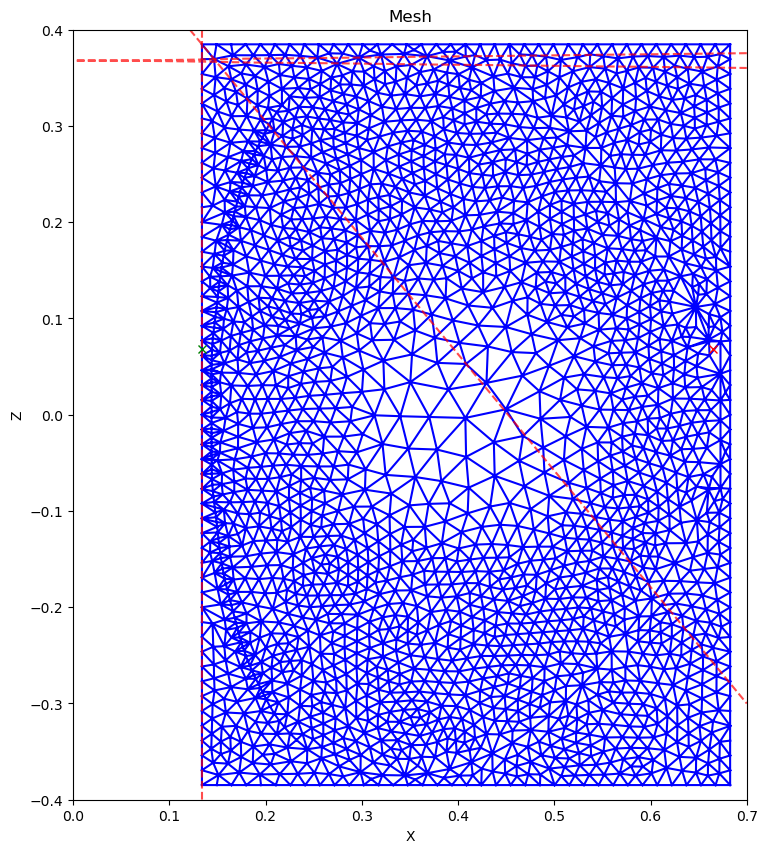

In [24]:
cell_id = 3448
cell_boundary_ids, signs = get_cell_boundaries(cell_id, cells, boundaries)
print(f"Cell {cell_id} boundaries: {cell_boundary_ids} with signs {signs}")
fig, ax = plt.subplots()
plot_triangulation_with_labels(mesh, axis=ax, node_numbers=False, triangle_numbers=False)
for b_id in cell_boundary_ids:
    plot_quad_on_xz(surface_coeffs[b_id], (0,0.7), (-0.4,0.4), axis=ax)

ax.plot(0.66454390013323439, 6.7984611975962131E-002, 'rx')
ax.plot(0.13394200000000012, 6.7984611975962131E-002, 'gx')
ax.set_xlabel('X')
ax.set_ylabel('Z')
# equal axis scaling
ax.set_aspect('equal')
ax.set_xlim(0,0.7)
ax.set_ylim(-0.4, 0.4)
fig.set_size_inches(10, 10)
plt.show()

(array([], dtype=int32), array([3448], dtype=int32))


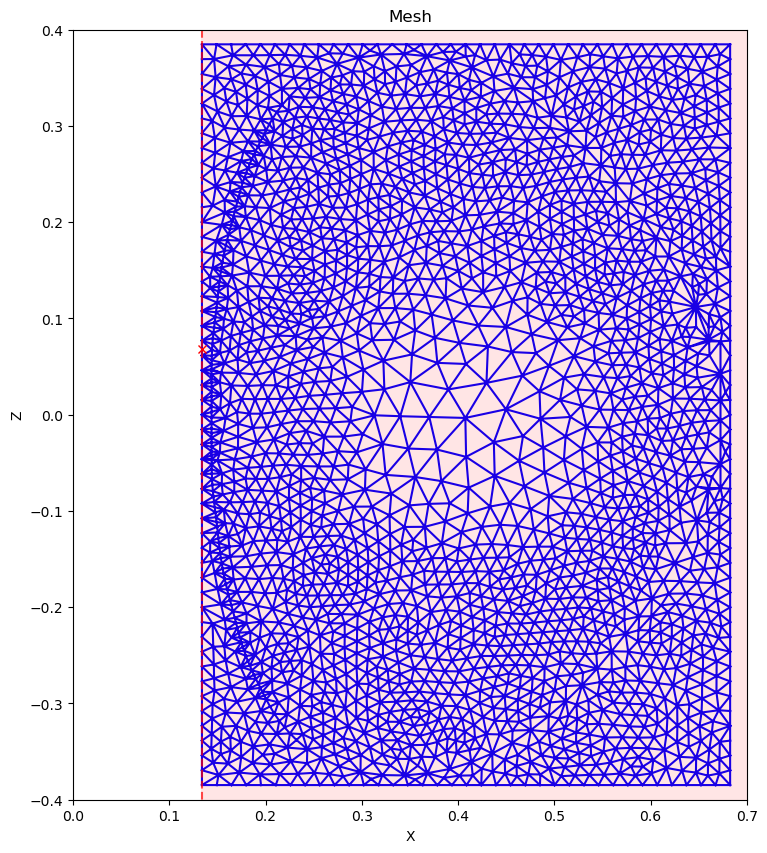

In [23]:
fig, ax = plt.subplots()
plot_triangulation_with_labels(mesh, axis=ax, triangle_numbers=False, node_numbers=False)

test_edge_id = 311
print(get_neighboring_cells(test_edge_id, surfaces, neighbors))
plot_quad_on_xz(surface_coeffs[test_edge_id], (0,0.7), (-0.4, 0.4), axis=ax, sign=1)

ax.plot(0.13394200000000012, 6.7984611975962131E-002, 'rx')
    
#plot_quad_on_xz(surface_coeffs[12], (0,5), (-5,5))
ax.set_xlabel('X')
ax.set_ylabel('Z')
# equal axis scaling
ax.set_aspect('equal')
ax.set_xlim(0,0.7)
ax.set_ylim(-0.4, 0.4)
fig.set_size_inches(10, 10)
plt.show()

In [21]:
get_cell_boundaries(0, cells, boundaries)

(array([189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201,
        202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214,
        215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227,
        228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240,
        241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253,
        254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266,
        267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279,
        280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292,
        293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305,
        306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318,
        319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331,
        332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344,
        345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357,
        358, 359, 360], dtype=int32),
 array([ 1,  

In [ ]:
surface_coeffs[29]

array([-0.5625,  0.    ,  0.    ,  1.5   ,  0.0625,  0.0625, -1.    ,
        0.    ,  0.    ,  0.    ,  1.    ])